# Nubank Credit Risk — Análise, Limpeza e Modelagem de ML

**Dataset:** Nubank Data Challenge (2018)  
**Problema:** Previsão de inadimplência em concessão de crédito  
**Tipo:** Classificação binária (`target_default`: 0 = adimplente, 1 = inadimplente)

**Integrantes**:

*   André Luiz Veras Fernandes

*   Henry Gabriel Santos Silva

*   Maria Eduarda Souza Romeu

*   Ruan Gomes Gonçalves da Silva



---

## Estrutura do Notebook

**Parte 1 — Com `facebook_profile`**
1. Configuração do Ambiente
2. Carregamento e Diagnóstico dos Dados
3. Limpeza e Preparação
4. Feature Engineering
5. Análise Exploratória (EDA)
6. Modelagem: sem balanceamento → RUS → SMOTE
7. Tabela Comparativa Final

**Parte 2 — Análise de Ablação: sem `facebook_profile`**
8. Repetição do pipeline sem a variável
9. Comparação direta com a Parte 1


## 1. Configuração do Ambiente

In [ ]:
# !pip install imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, f1_score)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13

print("Ambiente configurado.")

Ambiente configurado.


## 2. Carregamento e Diagnóstico dos Dados

O dataset `acquisition_train.csv` contém **45.000 registros** e **43 variáveis** coletadas no momento da aplicação de crédito — antes de qualquer decisão ser tomada. Esse contexto é fundamental: o modelo deve operar apenas com informações disponíveis *no momento da solicitação*.


In [ ]:
PATH_TRAIN = 'acquisition_train.csv'

df_raw = pd.read_csv(PATH_TRAIN)

# Guardar nulos originais antes da limpeza (para missing flags)
orig_nulls = {col: df_raw[col].isnull() for col in ['last_amount_borrowed','ok_since','n_issues']}

print(f"Shape: {df_raw.shape}")
print(f"Duplicatas: {df_raw.duplicated().sum()}")
df_raw.head(3)

Shape: (45000, 43)
Duplicatas: 0


,ids,target_default,score_1,score_2,score_3,score_4,score_5,score_6,risk_rate,last_amount_borrowed,...,external_data_provider_fraud_score,lat_lon,marketing_channel,profile_phone_number,reported_income,shipping_state,shipping_zip_code,profile_tags,user_agent,target_fraud
0,343b7e7b-2cf8-e508-b8fd-0a0285af30aa,False,1Rk8w4Ucd5yR3KcqZzLdow==,IOVu8au3ISbo6+zmfnYwMg==,350.0,101.800832,0.259555,108.427273,0.40,25033.92,...,645,"(-29.151545708122246, -51.1386461804385)",Invite-email,514-9840782,57849.0,BR-MT,17528,"{'tags': ['n19', 'n8']}",Mozilla/5.0 (Linux; Android 6.0.1; SGP771 Buil...,NaN
1,bc2c7502-bbad-0f8c-39c3-94e881967124,False,DGCQep2AE5QRkNCshIAlFQ==,SaamrHMo23l/3TwXOWgVzw==,370.0,97.062615,0.942655,92.002546,0.24,NaN,...,243,"(-19.687710705798963, -47.94151536525154)",Radio-commercial,251-3659293,4902.0,BR-RS,40933,"{'tags': ['n6', 'n7', 'nim']}",Mozilla/5.0 (Linux; Android 5.0.2; SAMSUNG SM-...,NaN
2,669630dd-2e6a-0396-84bf-455e5009c922,True,DGCQep2AE5QRkNCshIAlFQ==,Fv28Bz0YRTVAT5kl1bAV6g==,360.0,100.027073,0.351918,112.892453,0.29,7207.92,...,65,"(-28.748023890412284, -51.867279334353995)",Waiting-list,230-6097993,163679.0,BR-RR,50985,"{'tags': ['n0', 'n17', 'nim', 'da']}",Mozilla/5.0 (Linux; Android 6.0.1; SGP771 Buil...,NaN


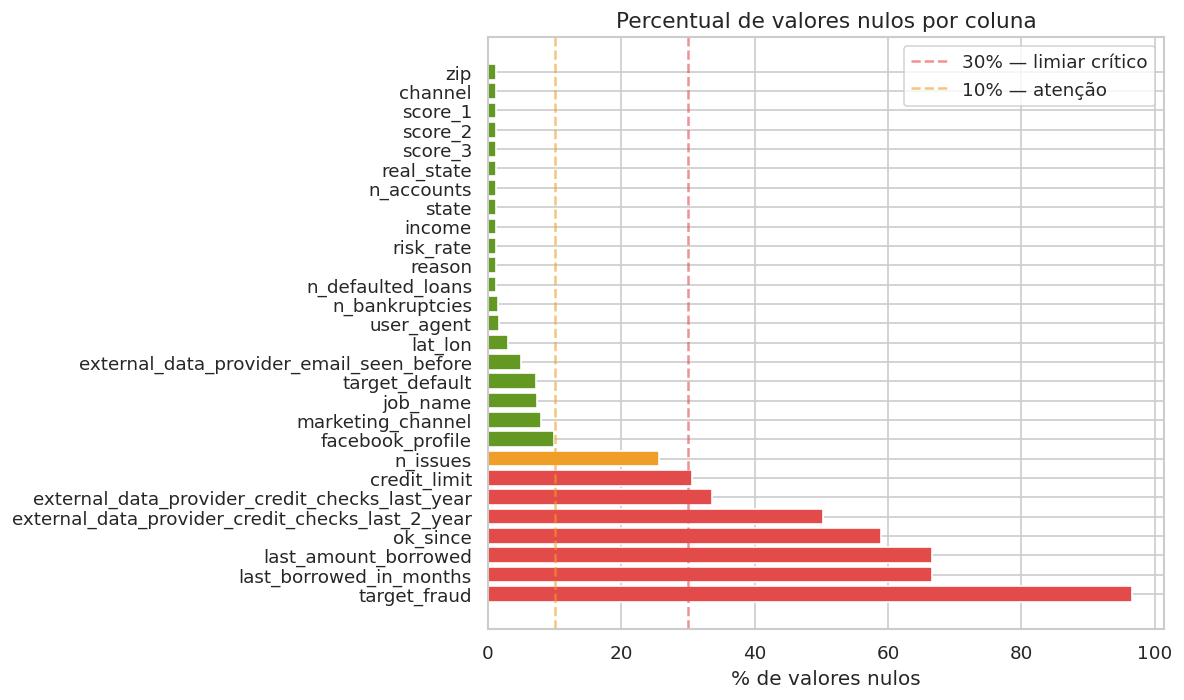

In [ ]:
nulos = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
nulos_df = nulos[nulos > 0].reset_index()
nulos_df.columns = ['coluna', 'pct_nulo']

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E24B4A' if v > 30 else '#EF9F27' if v > 10 else '#639922'
          for v in nulos_df['pct_nulo']]
ax.barh(nulos_df['coluna'], nulos_df['pct_nulo'], color=colors)
ax.axvline(30, color='#E24B4A', linestyle='--', alpha=0.6, label='30% — limiar crítico')
ax.axvline(10, color='#EF9F27', linestyle='--', alpha=0.6, label='10% — atenção')
ax.set_xlabel('% de valores nulos')
ax.set_title('Percentual de valores nulos por coluna')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Limpeza e Preparação dos Dados

A limpeza foi guiada por três perguntas:
1. **Esta coluna é utilizável?** — cardinalidade, criptografia, PII
2. **O nulo tem significado próprio?** — nulo ≠ ausente em dados financeiros
3. **Esta variável existe no momento da decisão?** — evitar data leakage


### 3.1 Remoção de Colunas Sem Valor Analítico

| Coluna | Motivo da remoção |
|---|---|
| `ids` | Identificador — não é feature preditiva |
| `channel` | Apenas 1 valor único — variância zero |
| `reason` | 14.874 categorias criptografadas |
| `job_name` | 32.265 categorias criptografadas |
| `profile_tags` | 24.458 categorias criptografadas |
| `zip` / `shipping_zip_code` | CEPs criptografados — redundantes com `state` |
| `external_data_provider_first_name` | PII — nome do cliente |
| `profile_phone_number` | PII — telefone |
| `user_agent` | Texto livre — alta cardinalidade, baixo ganho |
| `lat_lon` | Coordenadas em string — `state` já captura localização |
| `credit_limit` | **Data leakage** — definido *após* a aprovação |

> **Nota sobre `credit_limit`:** O limite de crédito só existe após a decisão de aprovação. Usá-lo como feature seria treinar o modelo com informação do futuro. Apesar da correlação baixa (-0.009 com `target_default`), a exclusão é uma decisão de princípio.


In [ ]:
df = df_raw.copy()

colunas_remover = [
    'ids', 'channel', 'reason', 'job_name', 'profile_tags',
    'zip', 'shipping_zip_code',
    'external_data_provider_first_name', 'profile_phone_number',
    'user_agent', 'lat_lon', 'credit_limit'
]
df.drop(columns=colunas_remover, inplace=True, errors='ignore')
print(f"Shape após remoção: {df.shape} (removidas {len(colunas_remover)} colunas)")

Shape após remoção: (45000, 31) (removidas 12 colunas)


### 3.2 Tratamento dos Targets

**`target_default`**: 3.259 registros nulos (7,2%). Como não conhecemos o desfecho real desses clientes, removemos as linhas — imputar o target introduziria viés direto no treinamento.

**`target_fraud`**: 96,6% dos valores são nulos. Nulo aqui tem significado claro: ausência de fraude. Convertemos para binário (0/1).


In [ ]:
# Remover nulos no target e converter tipos
df.dropna(subset=['target_default'], inplace=True)
df['target_default'] = df['target_default'].astype(str).map({'True':1,'False':0}).astype(int)
df['target_fraud']   = df['target_fraud'].notna().astype(int)

# facebook_profile: object → int antes dos fillnas categóricos
df['facebook_profile'] = (
    df['facebook_profile']
    .map({True:1, False:0, 'True':1, 'False':0})
    .fillna(0).astype(int)
)

print("Distribuição target_default:")
vc = df['target_default'].value_counts()
print(f"  Adimplente  (0): {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)")
print(f"  Inadimplente(1): {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)")
print(f"\nRazão de desbalanceamento: {vc[0]/vc[1]:.1f}:1")
print(f"\nShape: {df.shape}")

Distribuição target_default:
  Adimplente  (0): 35,080 (84.0%)
  Inadimplente(1): 6,661 (16.0%)

Razão de desbalanceamento: 5.3:1

Shape: (41741, 31)


### 3.3 Tratamento de Nulos por Grupo

#### Grupo A — Nulo semântico = 0
Nulo significa "nunca aconteceu", não dado ausente:
- `last_amount_borrowed`, `last_borrowed_in_months` → cliente nunca tomou empréstimo
- `ok_since` → cliente sem histórico de conta
- Consultas de crédito externas → sem histórico de consultas
- `n_issues` → sem pendências

#### Grupo B — Mediana (variáveis numéricas com baixo % de nulos)
Mediana preferida à média por ser robusta a outliers — comuns em dados financeiros.

#### Grupo C — Categóricos → moda ou 'Unknown'


In [ ]:
# Grupo A — Nulo semântico = 0
cols_zero = ['last_amount_borrowed', 'last_borrowed_in_months', 'ok_since',
             'external_data_provider_credit_checks_last_2_year',
             'external_data_provider_credit_checks_last_year', 'n_issues']
for col in cols_zero:
    df[col] = df[col].fillna(0)

# Grupo B — Mediana
cols_mediana = ['income', 'risk_rate', 'n_bankruptcies', 'n_defaulted_loans',
                'n_accounts', 'score_3', 'score_4', 'score_5', 'score_6',
                'external_data_provider_email_seen_before', 'reported_income']
for col in cols_mediana:
    df[col] = df[col].fillna(df[col].median())

# Grupo C — Categóricos
df['marketing_channel'] = df['marketing_channel'].fillna('Unknown')
df['state']             = df['state'].fillna('Unknown')
df['real_state']        = df['real_state'].fillna(df['real_state'].mode()[0])
df['score_1']           = df['score_1'].fillna(df['score_1'].mode()[0])
df['score_2']           = df['score_2'].fillna(df['score_2'].mode()[0])

print(f"Nulos restantes: {df.isnull().sum().sum()}")

Nulos restantes: 0


### 3.4 Correção de Valores Inválidos

`application_time_applied` contém 749 registros com minuto = 60 (ex: `'00:60:02'`) — artefato do sistema de coleta. Extraímos apenas a **hora do dia** (0–23) como variável numérica, preservando a informação temporal sem descartar registros.


In [ ]:
def extrair_hora(t):
    try:
        h = int(str(t).split(':')[0])
        return h if 0 <= h <= 23 else np.nan
    except:
        return np.nan

df['hora_aplicacao'] = df['application_time_applied'].apply(extrair_hora)
df['hora_aplicacao'] = df['hora_aplicacao'].fillna(12).astype(int)
df.drop(columns=['application_time_applied'], inplace=True)

print(f"Shape final da limpeza: {df.shape}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")

Shape final da limpeza: (41741, 31)
Nulos restantes: 0


## 4. Feature Engineering

Criação de variáveis derivadas das originais, com justificativa de negócio para cada uma.


In [ ]:
# Flags de histórico de crédito
df['has_previous_loan']    = (df['last_amount_borrowed'] > 0).astype(int)
df['has_previous_default'] = (df['n_defaulted_loans'] > 0).astype(int)
df['has_bankruptcy']       = (df['n_bankruptcies'] > 0).astype(int)
df['has_issues']           = (df['n_issues'] > 0).astype(int)

# Inconsistência de renda: diferença entre renda declarada e estimada
# Diferença grande pode indicar fraude ou erro cadastral
df['income_difference'] = df['reported_income'] - df['income']
df['income_ratio']      = df['reported_income'] / (df['income'] + 1)

# Aceleração de consultas de crédito: mês atual vs média mensal do ano
# Cliente consultando muito mais este mês pode estar em desespero financeiro
df['credit_check_acceleration'] = (
    df['external_data_provider_credit_checks_last_month'] /
    (df['external_data_provider_credit_checks_last_year'] / 12 + 0.01)
)

# Período do dia da aplicação
df['periodo_dia'] = pd.cut(
    df['hora_aplicacao'],
    bins=[-1, 6, 12, 18, 24],
    labels=['madrugada', 'manha', 'tarde', 'noite']
).astype(str)

# Clip de outliers + transformação log nas variáveis financeiras
for col in ['income', 'reported_income']:
    df[col] = df[col].clip(upper=df[col].quantile(0.99))
    df[f'{col}_log'] = np.log1p(df[col])

# Missing flags — captura o padrão de ausência como feature
for col in ['last_amount_borrowed', 'ok_since', 'n_issues']:
    df[f'{col}_missing'] = orig_nulls[col].reindex(df.index).fillna(False).astype(int)

print(f"Features criadas. Shape: {df.shape}")
print(f"Novas colunas: has_previous_loan, has_previous_default, has_bankruptcy,")
print(f"               has_issues, income_difference, income_ratio,")
print(f"               credit_check_acceleration, periodo_dia,")
print(f"               income_log, reported_income_log,")
print(f"               last_amount_borrowed_missing, ok_since_missing, n_issues_missing")

Features criadas. Shape: (41741, 44)
Novas colunas: has_previous_loan, has_previous_default, has_bankruptcy,
               has_issues, income_difference, income_ratio,
               credit_check_acceleration, periodo_dia,
               income_log, reported_income_log,
               last_amount_borrowed_missing, ok_since_missing, n_issues_missing


## 5. Análise Exploratória dos Dados (EDA)

Cada visualização tem um propósito e uma conclusão. O objetivo é contar a história que os dados revelam sobre inadimplência.


### 5.1 Desbalanceamento da variável alvo

Este é o problema central da modelagem: a base tem proporção de 5.3:1 entre adimplentes e inadimplentes. Um modelo que chuta sempre "adimplente" acerta 84% — mas é inútil para o Nubank.


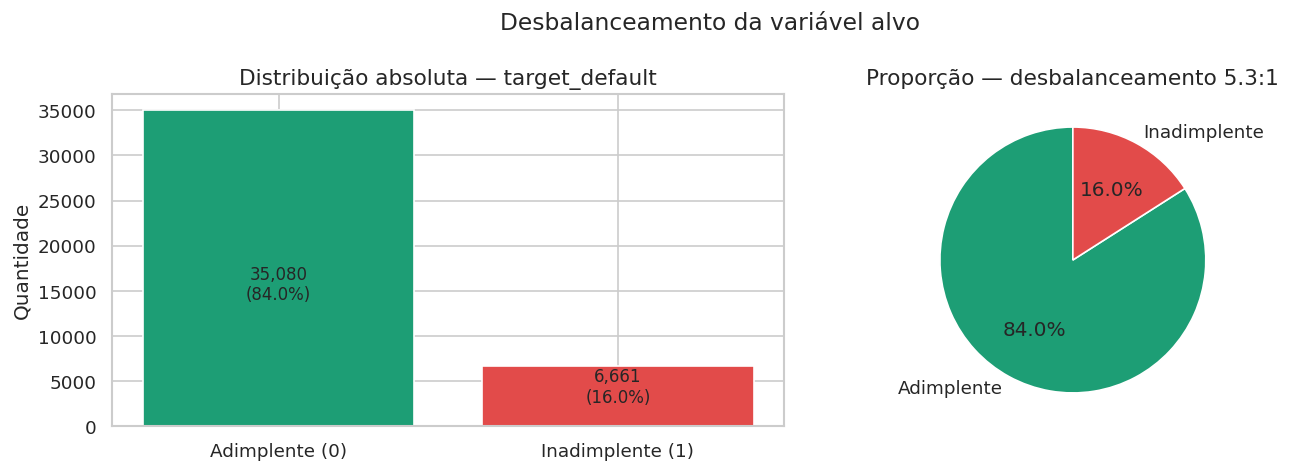

Razão: 5.3:1 — isso exige estratégias específicas de balanceamento na modelagem.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contagem absoluta
vc = df['target_default'].value_counts()
axes[0].bar(['Adimplente (0)', 'Inadimplente (1)'], vc.values,
            color=['#1D9E75', '#E24B4A'])
axes[0].set_title('Distribuição absoluta — target_default')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(vc.values):
    axes[0].text(i, v * 0.4, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

# Proporção
axes[1].pie(vc.values, labels=['Adimplente', 'Inadimplente'],
            colors=['#1D9E75','#E24B4A'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporção — desbalanceamento 5.3:1')

plt.suptitle('Desbalanceamento da variável alvo', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Razão: {vc[0]/vc[1]:.1f}:1 — isso exige estratégias específicas de balanceamento na modelagem.")

### 5.2 Risk rate por inadimplência

A variável `risk_rate` é a mais correlacionada com inadimplência (r = 0.097). O boxplot mostra que inadimplentes têm mediana de risco levemente maior, mas há grande sobreposição — nenhuma variável sozinha separa os grupos.

**Conclusão:** `risk_rate` é o sinal mais forte, mas o modelo precisa combinar múltiplas variáveis.


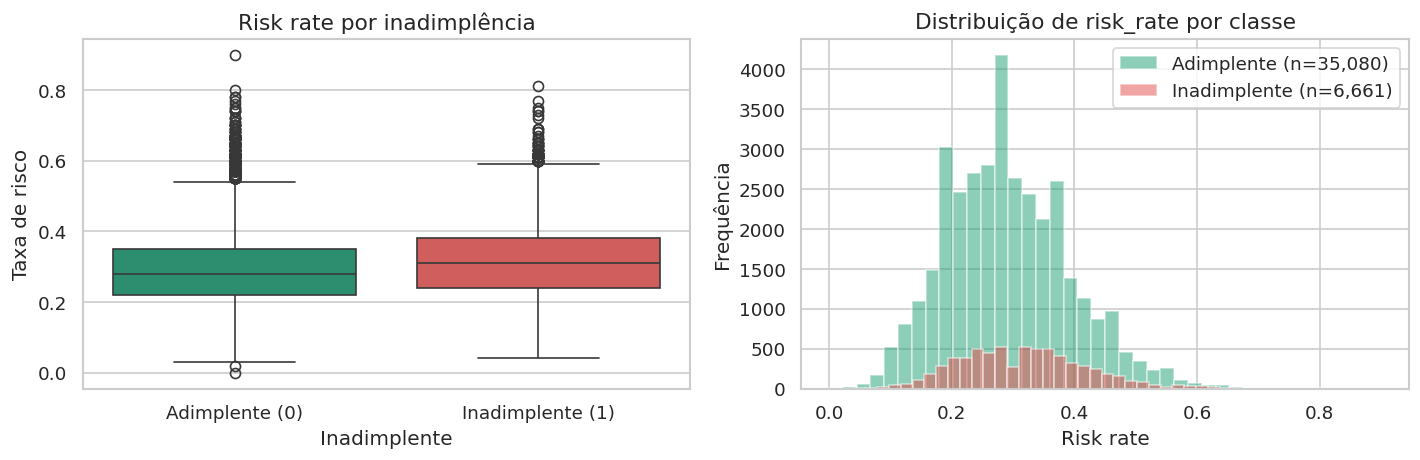

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(
    data=df,
    x='target_default',
    y='risk_rate',
    ax=axes[0],
    palette={'0':'#1D9E75', '1':'#E24B4A'}
)

axes[0].set_title('Risk rate por inadimplência')
axes[0].set_xlabel('Inadimplente')
axes[0].set_ylabel('Taxa de risco')
axes[0].set_xticklabels(['Adimplente (0)', 'Inadimplente (1)'])

for val, cor, label in [
    (0, '#1D9E75', 'Adimplente'),
    (1, '#E24B4A', 'Inadimplente')
]:
    subset = df[df['target_default'] == val]['risk_rate']

    axes[1].hist(
        subset,
        bins=40,
        alpha=0.5,
        color=cor,
        label=f'{label} (n={len(subset):,})'
    )

axes[1].set_title('Distribuição de risk_rate por classe')
axes[1].set_xlabel('Risk rate')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.3 Taxa de inadimplência por canal de marketing

Diferentes canais de aquisição apresentam perfis de risco distintos. O canal **Website** tem a maior taxa de inadimplência (em torno de 18,7%) enquanto **Invite-email** apresenta a menor (em torno de 13,5%).

**Conclusão de negócio:** O Nubank deveria aplicar critérios de aprovação mais rigorosos para clientes vindos pelo canal Website, ou ajustar a política de limite inicial por canal.


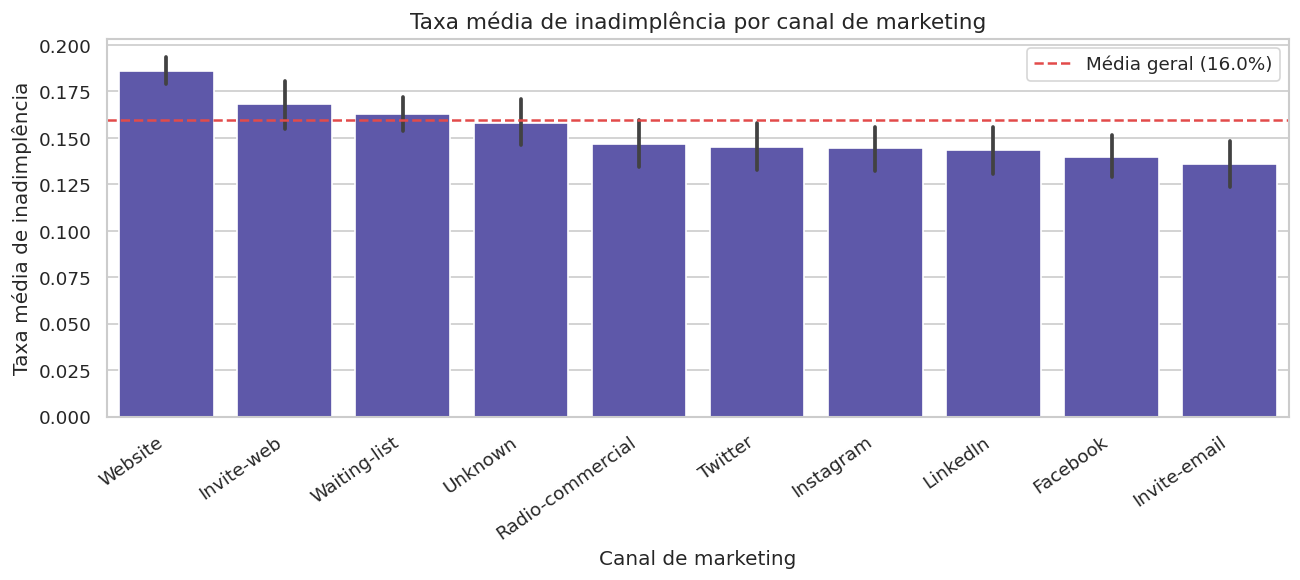

In [ ]:
plt.figure(figsize=(11, 5))
canal_order = (df.groupby('marketing_channel')['target_default']
               .mean().sort_values(ascending=False).index)
sns.barplot(data=df, x='marketing_channel', y='target_default',
            order=canal_order, estimator='mean', color='#534AB7')
plt.axhline(df['target_default'].mean(), color='#E24B4A',
            linestyle='--', label=f'Média geral ({df["target_default"].mean():.1%})')
plt.title('Taxa média de inadimplência por canal de marketing')
plt.xlabel('Canal de marketing')
plt.ylabel('Taxa média de inadimplência')
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 Matriz de correlação

Correlações lineares com `target_default` são geralmente baixas — inadimplência é um fenômeno multifatorial. As maiores correlações observadas:
- `risk_rate`: +0.097 (principal sinal)
- `application_hour`: -0.069 (aplicações de manhã têm menor risco)
- `income`: -0.043 (maior renda = menor inadimplência)


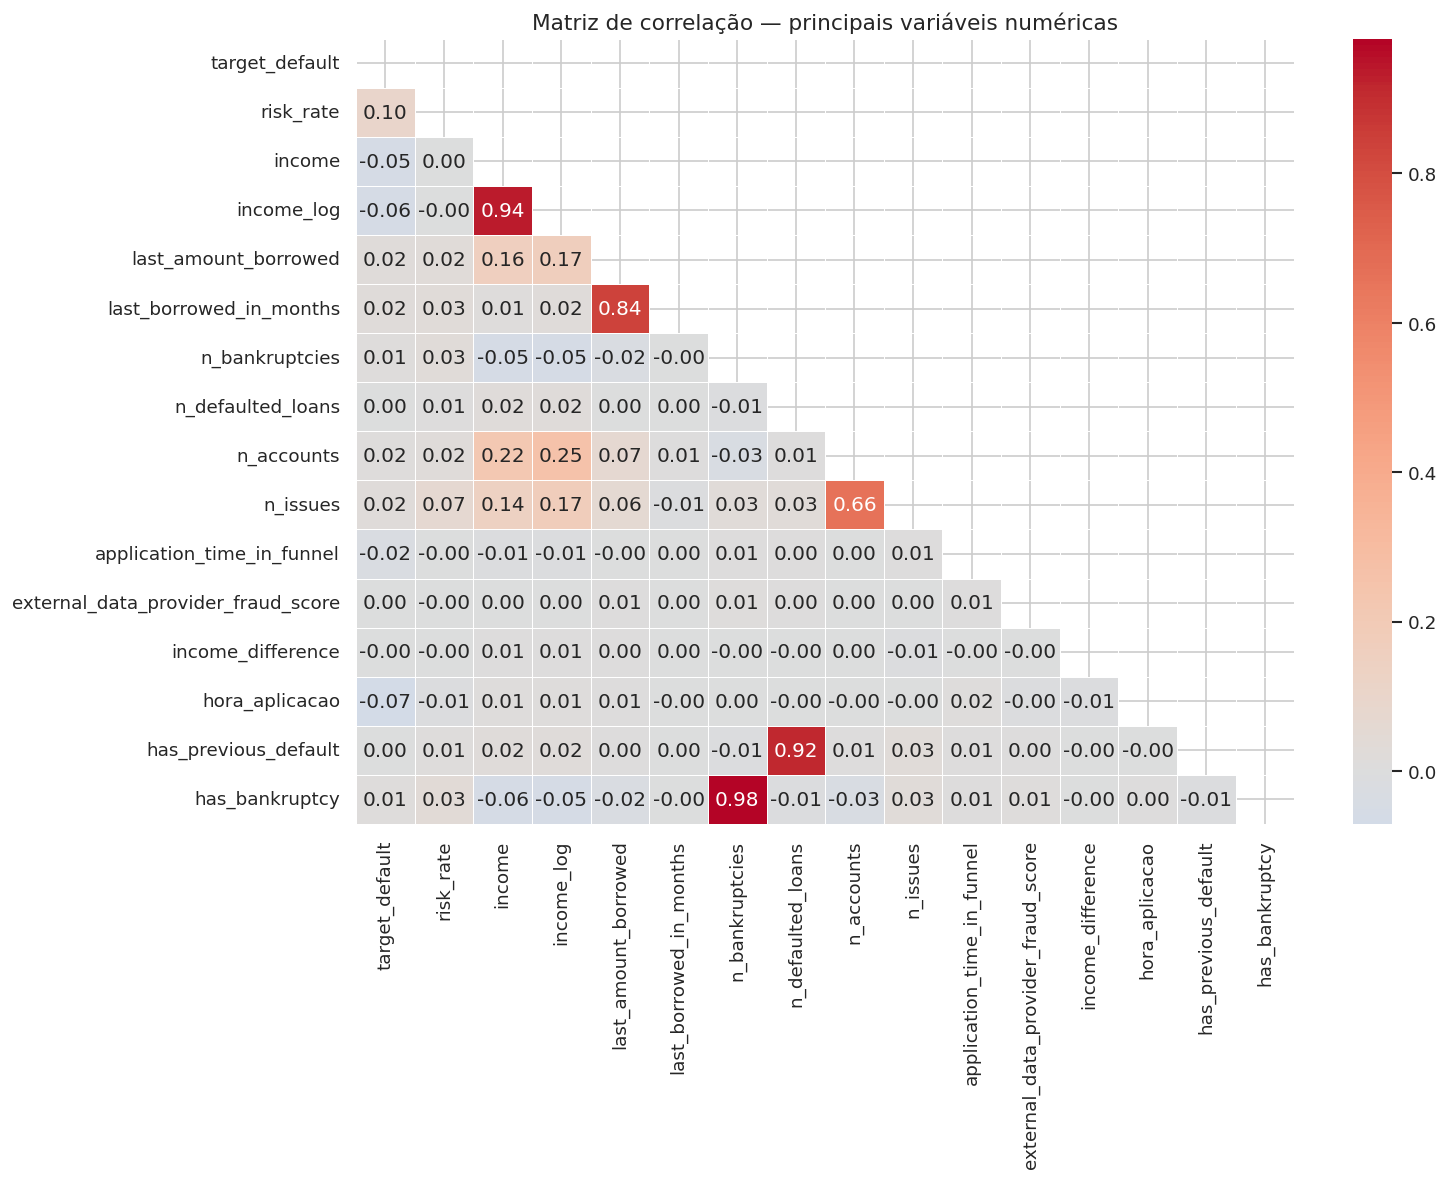

Top correlações com target_default:
risk_rate                  0.097
n_issues                   0.022
last_borrowed_in_months    0.022
last_amount_borrowed       0.017
n_accounts                 0.015
n_bankruptcies             0.014
has_bankruptcy             0.013
n_defaulted_loans          0.002
Name: target_default, dtype: float64


In [ ]:
cols_corr = ['target_default','risk_rate','income','income_log',
             'last_amount_borrowed','last_borrowed_in_months',
             'n_bankruptcies','n_defaulted_loans','n_accounts','n_issues',
             'application_time_in_funnel','external_data_provider_fraud_score',
             'income_difference','hora_aplicacao','has_previous_default','has_bankruptcy']
cols_corr = [c for c in cols_corr if c in df.columns]

plt.figure(figsize=(13, 10))
corr = df[cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, mask=mask)
plt.title('Matriz de correlação — principais variáveis numéricas')
plt.tight_layout()
plt.show()

print("Top correlações com target_default:")
print(corr['target_default'].sort_values(ascending=False).drop('target_default').head(8).round(3))

## 6. Preparação para Modelagem

Antes de treinar os modelos, preparamos as features: remoção de alta cardinalidade, encoding das variáveis categóricas e divisão treino/teste.


In [ ]:
# Separar features e target
X = df.drop(columns=['target_default', 'target_fraud'])
y = df['target_default']

# Remover colunas com cardinalidade > 50 (criptografadas, sem mapeamento)
cats = X.select_dtypes('object').columns
card = X[cats].nunique().sort_values(ascending=False)
print("Cardinalidade das variáveis categóricas:")
print(card)

drop_high = card[card > 50].index.tolist()
print(f"\nRemovendo por alta cardinalidade: {drop_high}")
X.drop(columns=drop_high, inplace=True)

# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True, dtype=int)
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median(numeric_only=True))

print(f"\nShape final de X: {X.shape}")

Cardinalidade das variáveis categóricas:
state                50
score_2              35
shipping_state       25
marketing_channel    10
score_1               7
email                 6
real_state            5
periodo_dia           4
dtype: int64

Removendo por alta cardinalidade: []

Shape final de X: (41741, 168)


In [ ]:
# Divisão treino/teste estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape} | Inadimplentes: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Teste:  {X_test.shape}  | Inadimplentes: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")
print("\nstratify=y garante a mesma proporção de inadimplentes nos dois conjuntos.")

Treino: (33392, 168) | Inadimplentes: 5,329 (16.0%)
Teste:  (8349, 168)  | Inadimplentes: 1,332 (16.0%)

stratify=y garante a mesma proporção de inadimplentes nos dois conjuntos.


### Funções auxiliares de avaliação

In [ ]:
def avaliar_modelos(modelos_pred, modelos_prob, y_test, titulo):
    """Exibe classification report, matriz de confusão e curva ROC para cada modelo."""
    print(f"\n{'='*60}")
    print(f"  {titulo}")
    print(f"{'='*60}")

    for nome in modelos_pred:
        y_pred = modelos_pred[nome]
        y_prob = modelos_prob[nome]
        auc = roc_auc_score(y_test, y_prob)
        print(f"\n--- {nome} (AUC: {auc:.4f}) ---")
        print(classification_report(y_test, y_pred,
              target_names=['Adimplente','Inadimplente']))

    # Matrizes de confusão
    fig, axes = plt.subplots(1, len(modelos_pred), figsize=(5*len(modelos_pred), 4))
    if len(modelos_pred) == 1:
        axes = [axes]
    for ax, (nome, y_pred) in zip(axes, modelos_pred.items()):
        cm = confusion_matrix(y_test, y_pred, normalize='true')
        ConfusionMatrixDisplay(cm, display_labels=['Adimpl.','Inadimpl.']).plot(
            ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'{nome}')
    plt.suptitle(f'Matrizes de Confusão (%) — {titulo}', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Curvas ROC
    plt.figure(figsize=(8, 6))
    for nome, y_prob in modelos_prob.items():
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{nome} (AUC={auc:.4f})')
    plt.plot([0,1],[0,1],'k--', label='Aleatório (AUC=0.5)')
    plt.xlabel('Taxa de Falso Positivo (FPR)')
    plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
    plt.title(f'Curvas ROC — {titulo}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

print("Funções de avaliação definidas.")

Funções de avaliação definidas.


## 7. Modelagem

### 7.1 Rodada 1 — Sem Balanceamento (Baseline)

Treinamos os modelos sem nenhuma técnica de balanceamento para estabelecer o baseline. O objetivo é mostrar como a acurácia alta (~84%) mascara um modelo que praticamente ignora a classe minoritária.



  Sem Balanceamento (Baseline)

--- Regressão Logística (AUC: 0.7184) ---
              precision    recall  f1-score   support

  Adimplente       0.85      0.99      0.91      7017
Inadimplente       0.47      0.05      0.09      1332

    accuracy                           0.84      8349
   macro avg       0.66      0.52      0.50      8349
weighted avg       0.79      0.84      0.78      8349


--- Árvore de Decisão (AUC: 0.6858) ---
              precision    recall  f1-score   support

  Adimplente       0.85      0.99      0.91      7017
Inadimplente       0.44      0.05      0.10      1332

    accuracy                           0.84      8349
   macro avg       0.64      0.52      0.50      8349
weighted avg       0.78      0.84      0.78      8349


--- Random Forest (AUC: 0.7231) ---
              precision    recall  f1-score   support

  Adimplente       0.84      1.00      0.91      7017
Inadimplente       0.00      0.00      0.00      1332

    accuracy                 

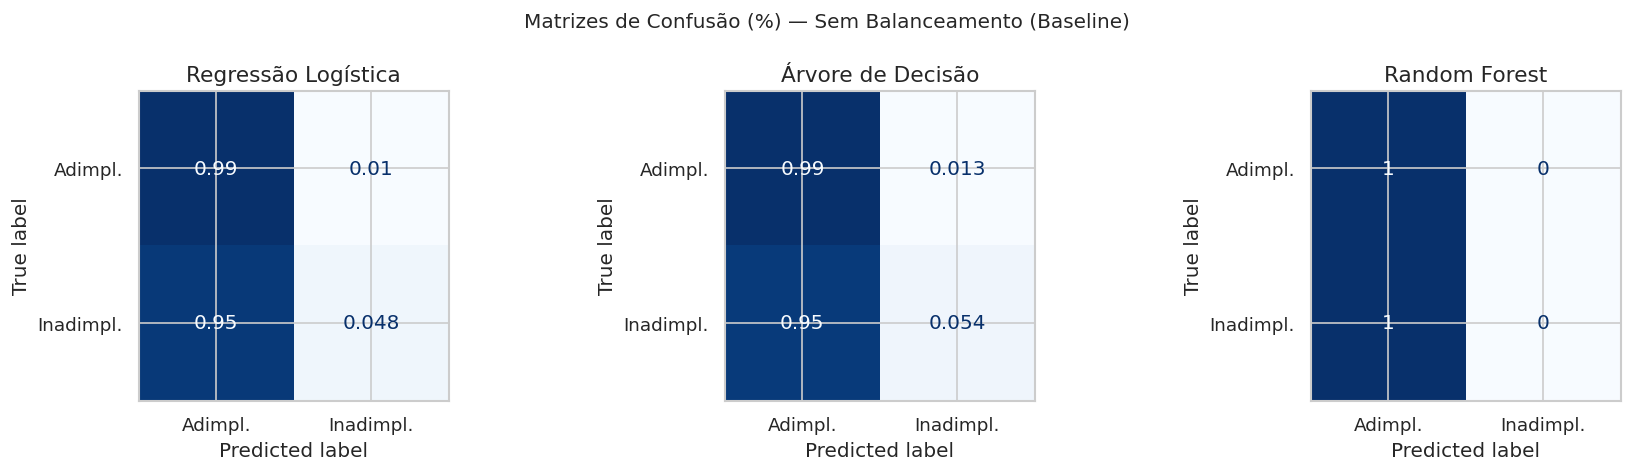

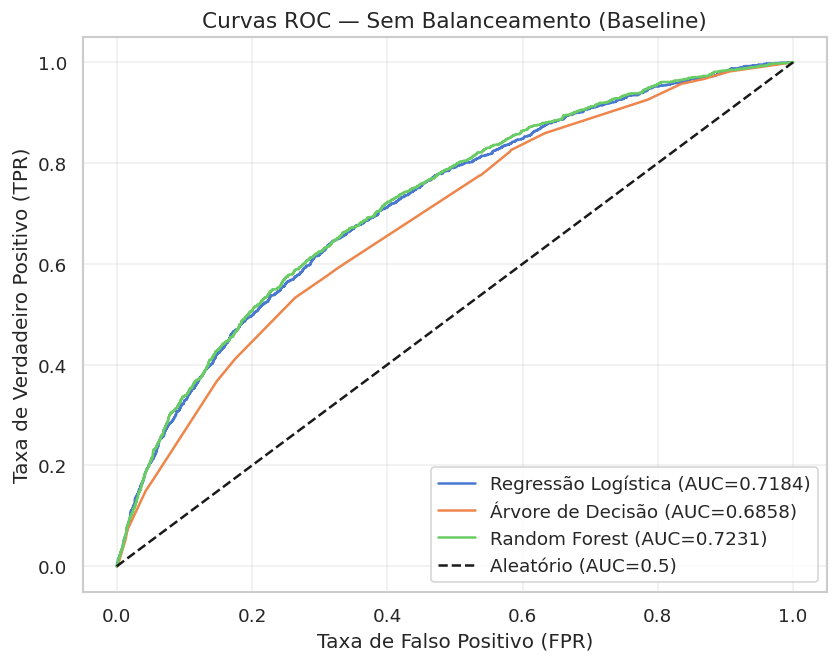

In [ ]:
# Scaler para Regressão Logística
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Treinar modelos
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_sc, y_train)

dt_base = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_base.fit(X_train, y_train)

rf_base = RandomForestClassifier(n_estimators=200, max_depth=12,
                                  min_samples_leaf=8, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

pred_base = {
    'Regressão Logística': lr_base.predict(X_test_sc),
    'Árvore de Decisão':   dt_base.predict(X_test),
    'Random Forest':       rf_base.predict(X_test)
}
prob_base = {
    'Regressão Logística': lr_base.predict_proba(X_test_sc)[:,1],
    'Árvore de Decisão':   dt_base.predict_proba(X_test)[:,1],
    'Random Forest':       rf_base.predict_proba(X_test)[:,1]
}

avaliar_modelos(pred_base, prob_base, y_test, 'Sem Balanceamento (Baseline)')

> **Observação:** Acurácia próxima de 84% com recall da classe 1 próximo de zero. O modelo aprendeu a dizer "adimplente" para quase todos os casos — estratégia inútil para o negócio.


### 7.2 Rodada 2 — Undersampling (RUS)

O RandomUnderSampler reduz a classe majoritária até igualar a minoritária. Isso força o modelo a aprender com um conjunto balanceado, melhorando o recall dos inadimplentes.

**Tradeoff:** perdemos ~22.000 exemplos da classe 0 — menos informação, mas modelo mais sensível.


In [ ]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

print(f"Antes do RUS: {y_train.value_counts().to_dict()}")
print(f"Após o RUS:   {y_rus.value_counts().to_dict()}")
print(f"Redução: {len(X_train)} → {len(X_rus)} amostras")

Antes do RUS: {0: 28063, 1: 5329}
Após o RUS:   {0: 5329, 1: 5329}
Redução: 33392 → 10658 amostras



  Undersampling — RUS

--- Logística (RUS) (AUC: 0.7157) ---
              precision    recall  f1-score   support

  Adimplente       0.91      0.65      0.76      7017
Inadimplente       0.27      0.67      0.38      1332

    accuracy                           0.65      8349
   macro avg       0.59      0.66      0.57      8349
weighted avg       0.81      0.65      0.70      8349


--- Árvore (RUS) (AUC: 0.6800) ---
              precision    recall  f1-score   support

  Adimplente       0.90      0.66      0.76      7017
Inadimplente       0.25      0.61      0.36      1332

    accuracy                           0.65      8349
   macro avg       0.58      0.63      0.56      8349
weighted avg       0.80      0.65      0.70      8349


--- Random Forest (RUS) (AUC: 0.7182) ---
              precision    recall  f1-score   support

  Adimplente       0.91      0.63      0.74      7017
Inadimplente       0.26      0.69      0.38      1332

    accuracy                           0.

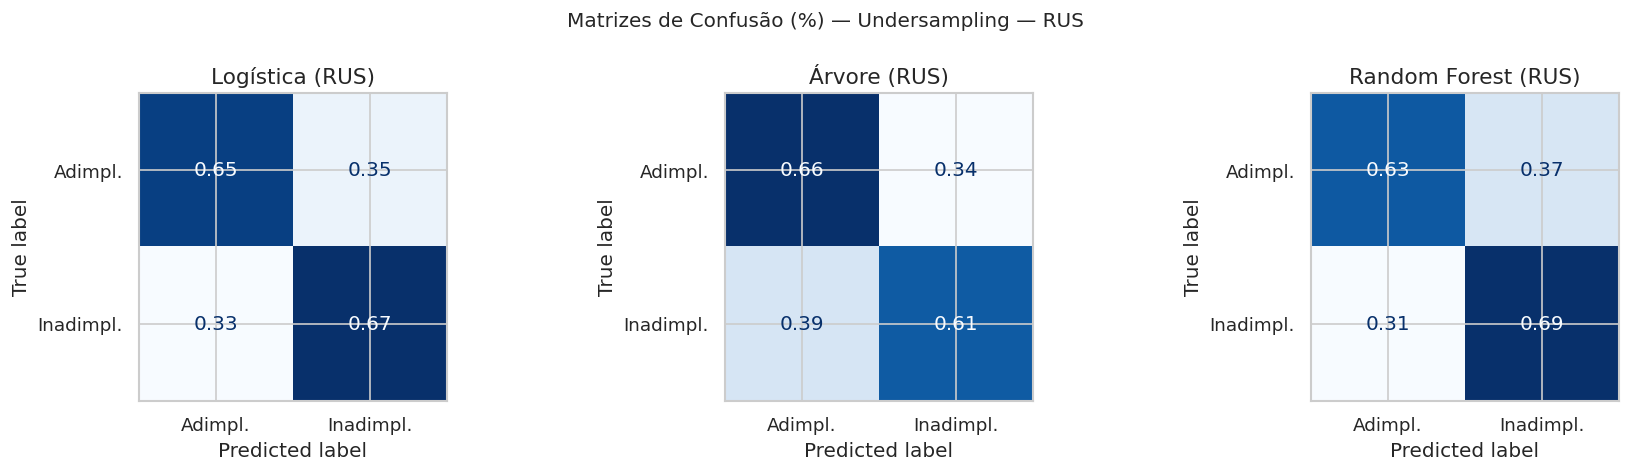

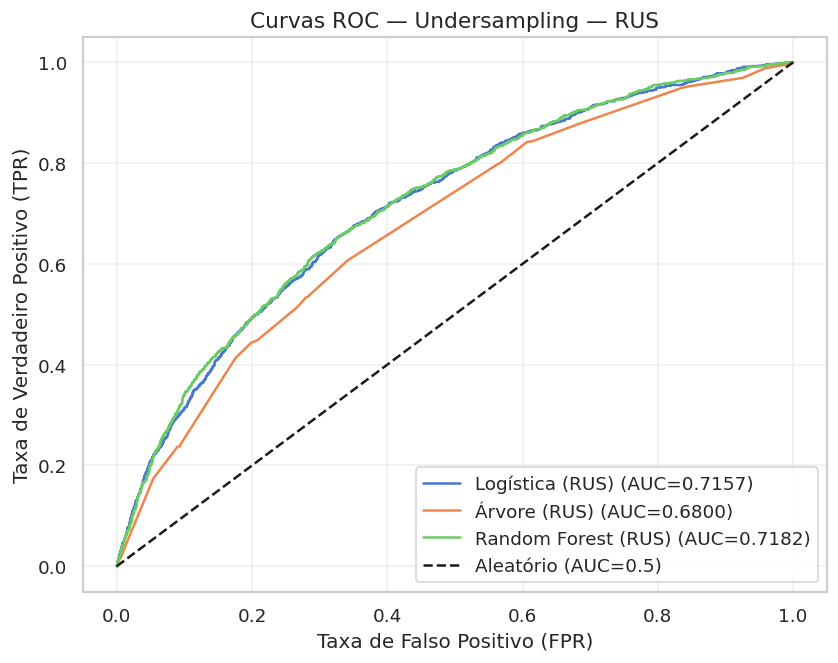

In [ ]:
# Scaler para Logística com RUS
scaler_rus = MinMaxScaler()
X_rus_sc      = scaler_rus.fit_transform(X_rus)
X_test_sc_rus = scaler_rus.transform(X_test)

lr_rus = LogisticRegression(max_iter=1000, random_state=42)
lr_rus.fit(X_rus_sc, y_rus)

dt_rus = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_rus.fit(X_rus, y_rus)

rf_rus = RandomForestClassifier(n_estimators=200, max_depth=12,
                                 min_samples_leaf=8, random_state=42, n_jobs=-1)
rf_rus.fit(X_rus, y_rus)

pred_rus = {
    'Logística (RUS)': lr_rus.predict(X_test_sc_rus),
    'Árvore (RUS)':    dt_rus.predict(X_test),
    'Random Forest (RUS)': rf_rus.predict(X_test)
}
prob_rus = {
    'Logística (RUS)': lr_rus.predict_proba(X_test_sc_rus)[:,1],
    'Árvore (RUS)':    dt_rus.predict_proba(X_test)[:,1],
    'Random Forest (RUS)': rf_rus.predict_proba(X_test)[:,1]
}

avaliar_modelos(pred_rus, prob_rus, y_test, 'Undersampling — RUS')

> **Observação:** O recall da classe 1 sobe significativamente (~69% no RF). O modelo passa a identificar mais inadimplentes, mas com mais falsos positivos — tradeoff aceitável no contexto de crédito, onde o custo de um inadimplente não detectado é alto.


### 7.3 Rodada 3 — Oversampling (SMOTE)

O SMOTE (Synthetic Minority Oversampling Technique) gera amostras sintéticas da classe minoritária interpolando entre exemplos existentes. Diferente do RUS, não perde dados — expande a base.

**Hipótese:** mais exemplos sintéticos de inadimplentes deveriam melhorar o modelo. Vamos verificar se isso se confirma.


In [ ]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

print(f"Antes do SMOTE: {y_train.value_counts().to_dict()}")
print(f"Após o SMOTE:   {y_sm.value_counts().to_dict()}")
print(f"Expansão: {len(X_train)} → {len(X_sm)} amostras")

Antes do SMOTE: {0: 28063, 1: 5329}
Após o SMOTE:   {0: 28063, 1: 28063}
Expansão: 33392 → 56126 amostras



  Oversampling — SMOTE

--- Logística (SMOTE) (AUC: 0.7127) ---
              precision    recall  f1-score   support

  Adimplente       0.85      0.99      0.91      7017
Inadimplente       0.45      0.06      0.10      1332

    accuracy                           0.84      8349
   macro avg       0.65      0.52      0.51      8349
weighted avg       0.78      0.84      0.78      8349


--- Árvore (SMOTE) (AUC: 0.6487) ---
              precision    recall  f1-score   support

  Adimplente       0.88      0.76      0.81      7017
Inadimplente       0.25      0.43      0.32      1332

    accuracy                           0.71      8349
   macro avg       0.57      0.60      0.57      8349
weighted avg       0.78      0.71      0.74      8349


--- Random Forest (SMOTE) (AUC: 0.6623) ---
              precision    recall  f1-score   support

  Adimplente       0.85      0.94      0.90      7017
Inadimplente       0.31      0.13      0.19      1332

    accuracy                      

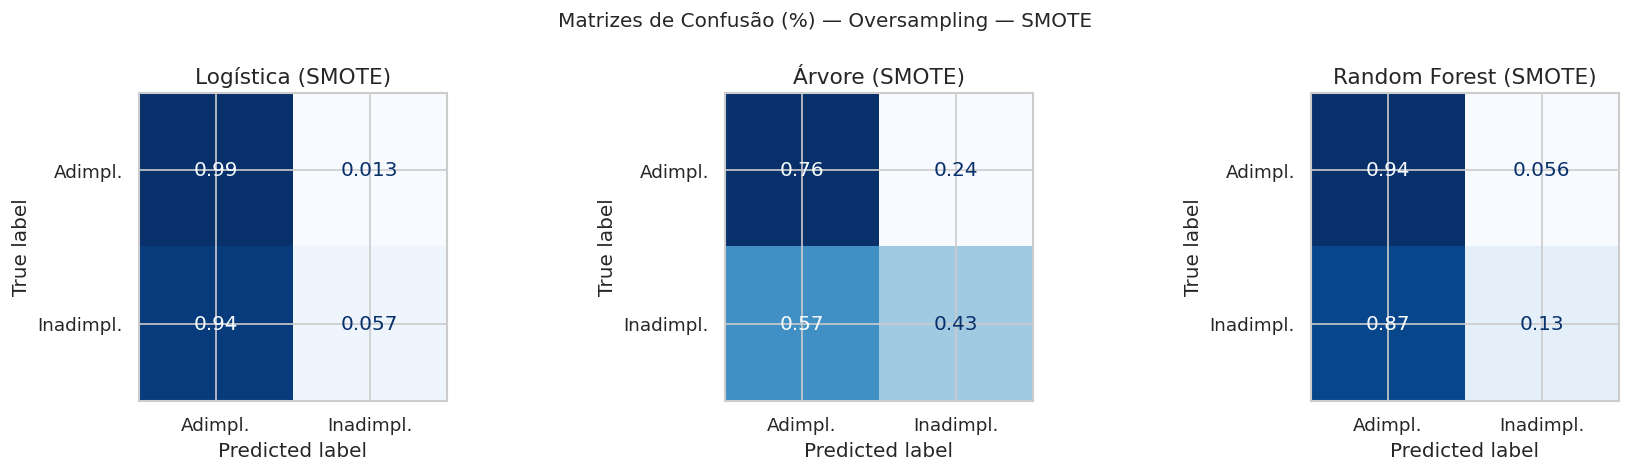

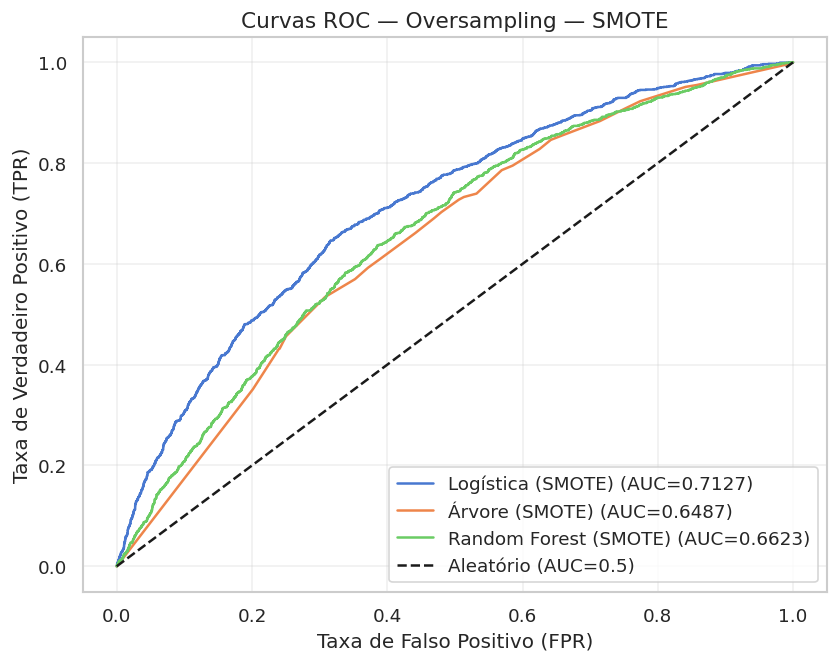

In [ ]:
scaler_sm = MinMaxScaler()
X_sm_sc      = scaler_sm.fit_transform(X_sm)
X_test_sc_sm = scaler_sm.transform(X_test)

lr_sm = LogisticRegression(max_iter=2000, random_state=42)
lr_sm.fit(X_sm_sc, y_sm)

dt_sm = DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)
dt_sm.fit(X_sm, y_sm)

rf_sm = RandomForestClassifier(n_estimators=200, max_depth=12,
                                min_samples_leaf=8, random_state=42, n_jobs=-1)
rf_sm.fit(X_sm, y_sm)

pred_sm = {
    'Logística (SMOTE)': lr_sm.predict(X_test_sc_sm),
    'Árvore (SMOTE)':    dt_sm.predict(X_test),
    'Random Forest (SMOTE)': rf_sm.predict(X_test)
}
prob_sm = {
    'Logística (SMOTE)': lr_sm.predict_proba(X_test_sc_sm)[:,1],
    'Árvore (SMOTE)':    dt_sm.predict_proba(X_test)[:,1],
    'Random Forest (SMOTE)': rf_sm.predict_proba(X_test)[:,1]
}

avaliar_modelos(pred_sm, prob_sm, y_test, 'Oversampling — SMOTE')

> **Resultado inesperado:** O SMOTE piorou o desempenho em relação ao RUS. O Random Forest com dados sintéticos obteve AUC e F1 inferiores. **Por quê?** O RF já possui mecanismo interno de penalização por desbalanceamento (`class_weight`). Adicionar amostras sintéticas introduziu ruído no espaço de features — os exemplos gerados pelo SMOTE eram artificiais e dificultaram a generalização do modelo.


### 7.4 Tabela Comparativa Final e Feature Importance


In [ ]:
# Tabela comparativa
resultados = []
todos_modelos = {
    'LR Baseline':   (pred_base['Regressão Logística'], prob_base['Regressão Logística']),
    'DT Baseline':   (pred_base['Árvore de Decisão'],   prob_base['Árvore de Decisão']),
    'RF Baseline':   (pred_base['Random Forest'],        prob_base['Random Forest']),
    'LR RUS':        (pred_rus['Logística (RUS)'],       prob_rus['Logística (RUS)']),
    'DT RUS':        (pred_rus['Árvore (RUS)'],          prob_rus['Árvore (RUS)']),
    'RF RUS':        (pred_rus['Random Forest (RUS)'],   prob_rus['Random Forest (RUS)']),
    'LR SMOTE':      (pred_sm['Logística (SMOTE)'],      prob_sm['Logística (SMOTE)']),
    'DT SMOTE':      (pred_sm['Árvore (SMOTE)'],         prob_sm['Árvore (SMOTE)']),
    'RF SMOTE':      (pred_sm['Random Forest (SMOTE)'],  prob_sm['Random Forest (SMOTE)']),
}

for nome, (y_pred, y_prob) in todos_modelos.items():
    from sklearn.metrics import precision_score, recall_score
    resultados.append({
        'Modelo': nome,
        'AUC':       round(roc_auc_score(y_test, y_prob), 4),
        'F1 cl.1':   round(f1_score(y_test, y_pred, pos_label=1), 3),
        'Recall cl.1':    round(recall_score(y_test, y_pred, pos_label=1), 3),
        'Precision cl.1': round(precision_score(y_test, y_pred, pos_label=1, zero_division=0), 3),
        'Acurácia': round((y_pred == y_test).mean(), 3)
    })

res_df = pd.DataFrame(resultados).sort_values('AUC', ascending=False)
print(res_df.to_string(index=False))


     Modelo    AUC  F1 cl.1  Recall cl.1  Precision cl.1  Acurácia
RF Baseline 0.7231    0.000        0.000           0.000     0.840
LR Baseline 0.7184    0.087        0.048           0.474     0.840
     RF RUS 0.7182    0.377        0.687           0.260     0.638
     LR RUS 0.7157    0.383        0.672           0.268     0.655
   LR SMOTE 0.7127    0.101        0.057           0.450     0.838
DT Baseline 0.6858    0.096        0.054           0.436     0.838
     DT RUS 0.6800    0.356        0.607           0.252     0.650
   RF SMOTE 0.6623    0.186        0.133           0.309     0.814
   DT SMOTE 0.6487    0.320        0.432           0.255     0.708


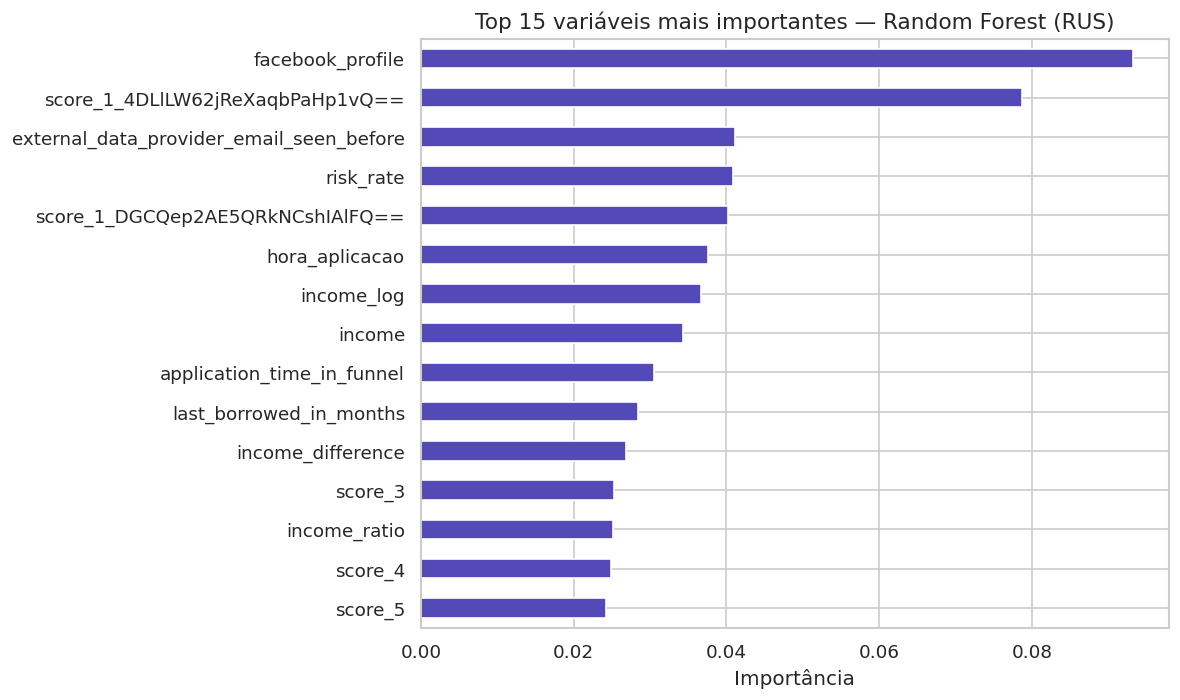


Top 15 features:
  facebook_profile: 0.0933
  score_1_4DLlLW62jReXaqbPaHp1vQ==: 0.0787
  external_data_provider_email_seen_before: 0.0412
  risk_rate: 0.0409
  score_1_DGCQep2AE5QRkNCshIAlFQ==: 0.0403
  hora_aplicacao: 0.0376
  income_log: 0.0367
  income: 0.0343
  application_time_in_funnel: 0.0306
  last_borrowed_in_months: 0.0284
  income_difference: 0.0269
  score_3: 0.0252
  income_ratio: 0.0252
  score_4: 0.0249
  score_5: 0.0242


In [ ]:
# Feature Importance do melhor Random Forest (RUS)
fi = pd.Series(rf_rus.feature_importances_, index=X.columns)
fi_top = fi.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
fi_top.sort_values().plot(kind='barh', color='#534AB7')
plt.title('Top 15 variáveis mais importantes — Random Forest (RUS)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
for feat, imp in fi_top.items():
    print(f"  {feat}: {imp:.4f}")

### 7.5 Conclusão de Negócio

**Modelo vencedor: Random Forest com RUS**

Com AUC de ~0.72 e recall de ~69% na classe inadimplente, o modelo identifica corretamente a maioria dos clientes de alto risco **antes** de conceder o crédito.

**O que o Nubank deveria fazer com esse modelo:**

1. **Usar o Random Forest (RUS) como triagem inicial** — clientes com probabilidade > 0.5 entram em análise manual antes da aprovação automática
2. **Ajustar o limite inicial por canal** — clientes vindos pelo Website (maior taxa de inadimplência) deveriam receber limites menores no início
3. **Monitorar `facebook_profile`** — é a feature mais importante. Se o Nubank deixar de coletar esse dado, o modelo perde poder preditivo
4. **Retreinar periodicamente** — padrões de inadimplência mudam com o ciclo econômico. O modelo deve ser avaliado a cada trimestre usando métricas de negócio: valor médio dos créditos inadimplentes detectados vs. não detectados


---

## Parte 2 — Análise de Ablação: Sem `facebook_profile`

Repetimos o pipeline completo removendo `facebook_profile`. Essa técnica — chamada de **análise de ablação** — isola o impacto de uma variável específica mantendo tudo igual.

**Hipótese:** se `facebook_profile` é a feature mais importante (10.18% de importância no RF), removê-la deve piorar o modelo de forma mensurável.


In [ ]:
# Pipeline idêntico — única diferença: facebook_profile removido
df2 = df_raw.copy()

colunas_remover_2 = colunas_remover + ['facebook_profile']
df2.drop(columns=colunas_remover_2, inplace=True, errors='ignore')
df2.dropna(subset=['target_default'], inplace=True)
df2['target_default'] = df2['target_default'].astype(str).map({'True':1,'False':0}).astype(int)
df2['target_fraud']   = df2['target_fraud'].notna().astype(int)

for col in cols_zero:
    df2[col] = df2[col].fillna(0)
for col in cols_mediana:
    df2[col] = df2[col].fillna(df2[col].median())

df2['marketing_channel'] = df2['marketing_channel'].fillna('Unknown')
df2['state']             = df2['state'].fillna('Unknown')
df2['real_state']        = df2['real_state'].fillna(df2['real_state'].mode()[0])
df2['score_1']           = df2['score_1'].fillna(df2['score_1'].mode()[0])
df2['score_2']           = df2['score_2'].fillna(df2['score_2'].mode()[0])

df2['hora_aplicacao'] = df2['application_time_applied'].apply(extrair_hora).fillna(12).astype(int)
df2.drop(columns=['application_time_applied'], inplace=True)

# Feature Engineering idêntico
df2['has_previous_loan']    = (df2['last_amount_borrowed'] > 0).astype(int)
df2['has_previous_default'] = (df2['n_defaulted_loans'] > 0).astype(int)
df2['has_bankruptcy']       = (df2['n_bankruptcies'] > 0).astype(int)
df2['has_issues']           = (df2['n_issues'] > 0).astype(int)
df2['income_difference']    = df2['reported_income'] - df2['income']
df2['income_ratio']         = df2['reported_income'] / (df2['income'] + 1)
df2['credit_check_acceleration'] = (
    df2['external_data_provider_credit_checks_last_month'] /
    (df2['external_data_provider_credit_checks_last_year'] / 12 + 0.01))
df2['periodo_dia'] = pd.cut(df2['hora_aplicacao'],
    bins=[-1,6,12,18,24], labels=['madrugada','manha','tarde','noite']).astype(str)
for col in ['income','reported_income']:
    df2[col] = df2[col].clip(upper=df2[col].quantile(0.99))
    df2[f'{col}_log'] = np.log1p(df2[col])
for col in ['last_amount_borrowed','ok_since','n_issues']:
    df2[f'{col}_missing'] = orig_nulls[col].reindex(df2.index).fillna(False).astype(int)

print(f"Shape sem facebook_profile: {df2.shape}")
print(f"Nulos: {df2.isnull().sum().sum()}")

Shape sem facebook_profile: (41741, 43)
Nulos: 0


In [ ]:
# Preparação
X2 = df2.drop(columns=['target_default','target_fraud'])
y2 = df2['target_default']

cats2 = X2.select_dtypes('object').columns
card2 = X2[cats2].nunique()
X2.drop(columns=card2[card2 > 50].index.tolist(), inplace=True)
X2 = pd.get_dummies(X2, drop_first=True, dtype=int)
X2 = X2.replace([np.inf,-np.inf], np.nan).fillna(X2.median(numeric_only=True))

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

print(f"Features: {X2.shape[1]} (vs {X.shape[1]} com facebook)")

Features: 167 (vs 168 com facebook)



  Sem Facebook — Baseline

--- LR Baseline (s/ FB) (AUC: 0.6899) ---
              precision    recall  f1-score   support

  Adimplente       0.84      0.99      0.91      7017
Inadimplente       0.49      0.03      0.05      1332

    accuracy                           0.84      8349
   macro avg       0.67      0.51      0.48      8349
weighted avg       0.79      0.84      0.78      8349


--- DT Baseline (s/ FB) (AUC: 0.6621) ---
              precision    recall  f1-score   support

  Adimplente       0.84      1.00      0.91      7017
Inadimplente       0.47      0.01      0.01      1332

    accuracy                           0.84      8349
   macro avg       0.65      0.50      0.46      8349
weighted avg       0.78      0.84      0.77      8349


--- RF Baseline (s/ FB) (AUC: 0.6966) ---
              precision    recall  f1-score   support

  Adimplente       0.84      1.00      0.91      7017
Inadimplente       0.00      0.00      0.00      1332

    accuracy              

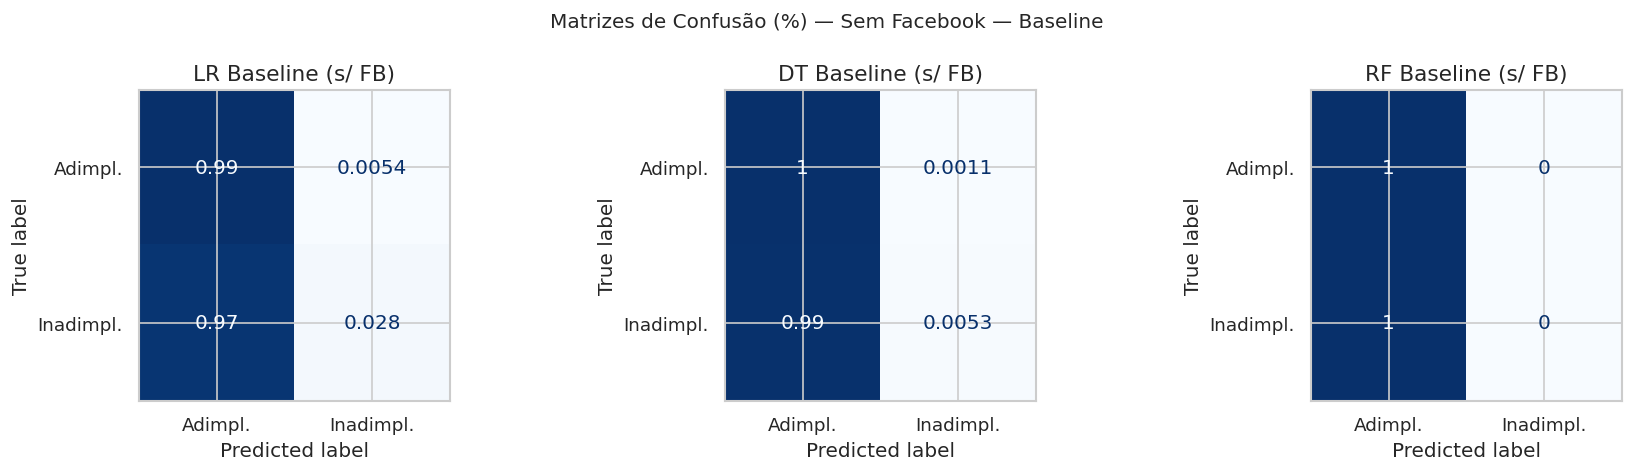

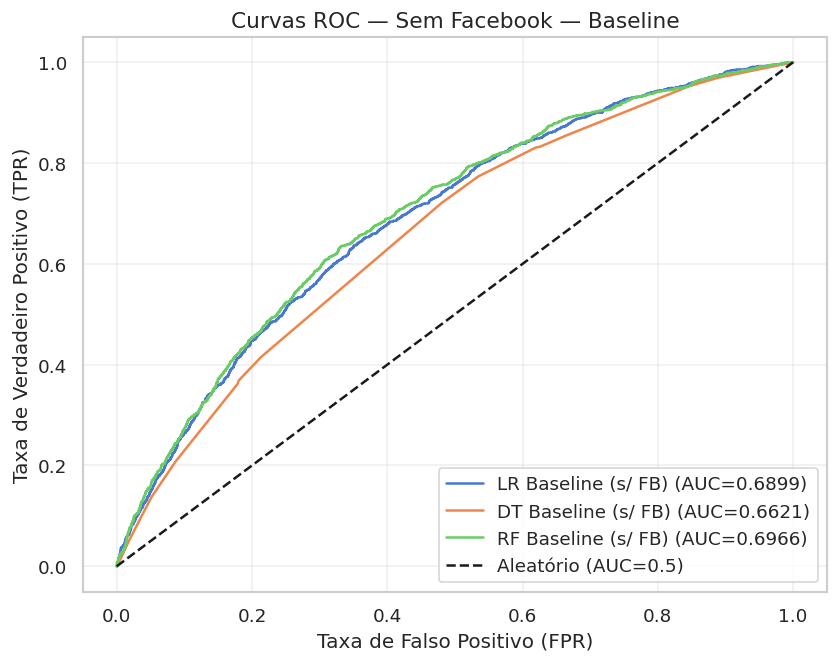

In [ ]:
# Rodada 1 — Sem balanceamento
scaler2 = MinMaxScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

lr2_base = LogisticRegression(max_iter=1000, random_state=42)
lr2_base.fit(X2_train_sc, y2_train)
dt2_base = DecisionTreeClassifier(max_depth=5, random_state=42)
dt2_base.fit(X2_train, y2_train)
rf2_base = RandomForestClassifier(n_estimators=200, max_depth=12,
                                   min_samples_leaf=8, random_state=42, n_jobs=-1)
rf2_base.fit(X2_train, y2_train)

pred2_base = {
    'LR Baseline (s/ FB)': lr2_base.predict(X2_test_sc),
    'DT Baseline (s/ FB)': dt2_base.predict(X2_test),
    'RF Baseline (s/ FB)': rf2_base.predict(X2_test)
}
prob2_base = {
    'LR Baseline (s/ FB)': lr2_base.predict_proba(X2_test_sc)[:,1],
    'DT Baseline (s/ FB)': dt2_base.predict_proba(X2_test)[:,1],
    'RF Baseline (s/ FB)': rf2_base.predict_proba(X2_test)[:,1]
}
avaliar_modelos(pred2_base, prob2_base, y2_test, 'Sem Facebook — Baseline')


  Sem Facebook — RUS

--- LR RUS (s/ FB) (AUC: 0.6856) ---
              precision    recall  f1-score   support

  Adimplente       0.90      0.64      0.75      7017
Inadimplente       0.25      0.63      0.36      1332

    accuracy                           0.64      8349
   macro avg       0.58      0.64      0.55      8349
weighted avg       0.80      0.64      0.68      8349


--- DT RUS (s/ FB) (AUC: 0.6545) ---
              precision    recall  f1-score   support

  Adimplente       0.91      0.52      0.66      7017
Inadimplente       0.22      0.72      0.34      1332

    accuracy                           0.55      8349
   macro avg       0.56      0.62      0.50      8349
weighted avg       0.80      0.55      0.61      8349


--- RF RUS (s/ FB) (AUC: 0.6924) ---
              precision    recall  f1-score   support

  Adimplente       0.91      0.61      0.73      7017
Inadimplente       0.25      0.68      0.36      1332

    accuracy                           0.62   

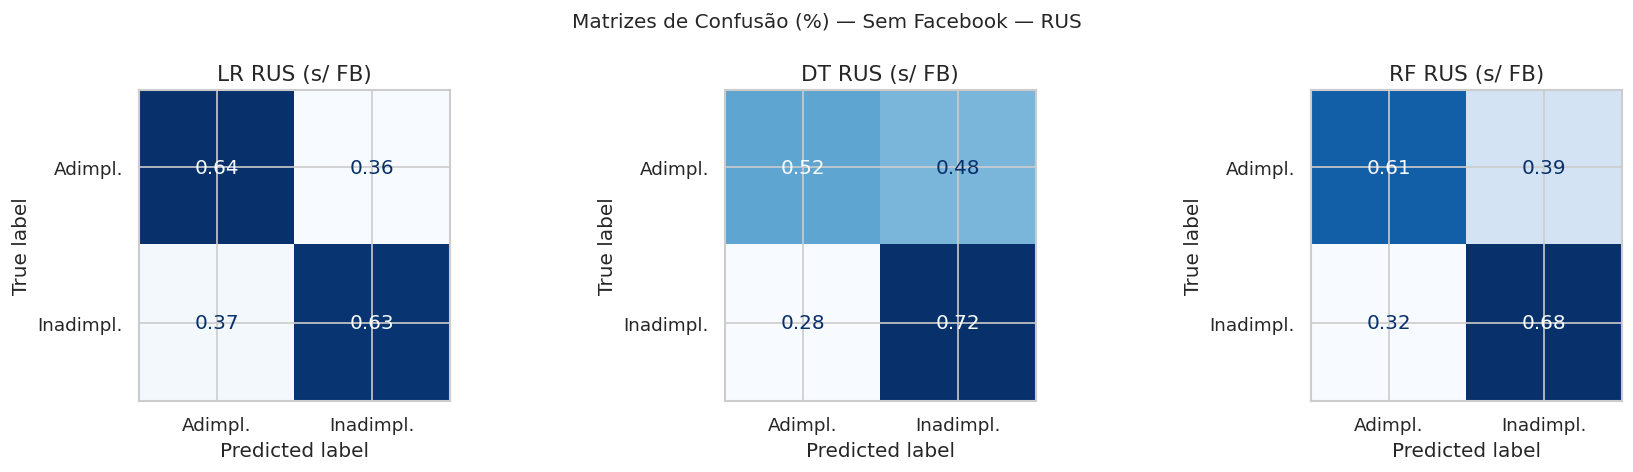

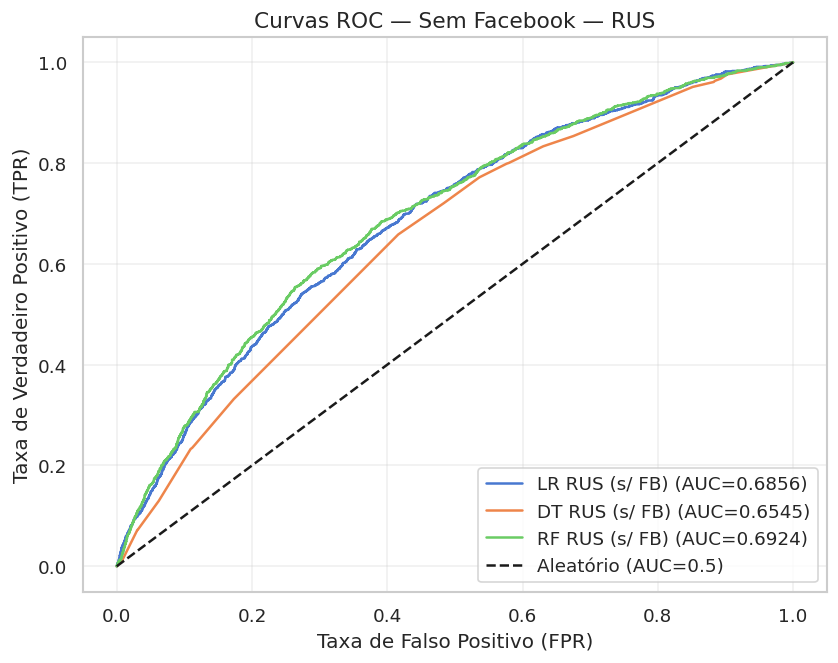

In [ ]:
# Rodada 2 — RUS
rus2 = RandomUnderSampler(random_state=42)
X2_rus, y2_rus = rus2.fit_resample(X2_train, y2_train)

scaler2_rus  = MinMaxScaler()
X2_rus_sc    = scaler2_rus.fit_transform(X2_rus)
X2_test_sc_rus = scaler2_rus.transform(X2_test)

lr2_rus = LogisticRegression(max_iter=1000, random_state=42)
lr2_rus.fit(X2_rus_sc, y2_rus)
dt2_rus = DecisionTreeClassifier(max_depth=5, random_state=42)
dt2_rus.fit(X2_rus, y2_rus)
rf2_rus = RandomForestClassifier(n_estimators=200, max_depth=12,
                                  min_samples_leaf=8, random_state=42, n_jobs=-1)
rf2_rus.fit(X2_rus, y2_rus)

pred2_rus = {
    'LR RUS (s/ FB)': lr2_rus.predict(X2_test_sc_rus),
    'DT RUS (s/ FB)': dt2_rus.predict(X2_test),
    'RF RUS (s/ FB)': rf2_rus.predict(X2_test)
}
prob2_rus = {
    'LR RUS (s/ FB)': lr2_rus.predict_proba(X2_test_sc_rus)[:,1],
    'DT RUS (s/ FB)': dt2_rus.predict_proba(X2_test)[:,1],
    'RF RUS (s/ FB)': rf2_rus.predict_proba(X2_test)[:,1]
}
avaliar_modelos(pred2_rus, prob2_rus, y2_test, 'Sem Facebook — RUS')


  Sem Facebook — SMOTE

--- LR SMOTE (s/ FB) (AUC: 0.6831) ---
              precision    recall  f1-score   support

  Adimplente       0.84      0.99      0.91      7017
Inadimplente       0.43      0.04      0.07      1332

    accuracy                           0.84      8349
   macro avg       0.64      0.51      0.49      8349
weighted avg       0.78      0.84      0.78      8349


--- DT SMOTE (s/ FB) (AUC: 0.6425) ---
              precision    recall  f1-score   support

  Adimplente       0.88      0.76      0.81      7017
Inadimplente       0.25      0.43      0.32      1332

    accuracy                           0.71      8349
   macro avg       0.56      0.60      0.57      8349
weighted avg       0.78      0.71      0.73      8349


--- RF SMOTE (s/ FB) (AUC: 0.6578) ---
              precision    recall  f1-score   support

  Adimplente       0.85      0.94      0.89      7017
Inadimplente       0.29      0.12      0.17      1332

    accuracy                          

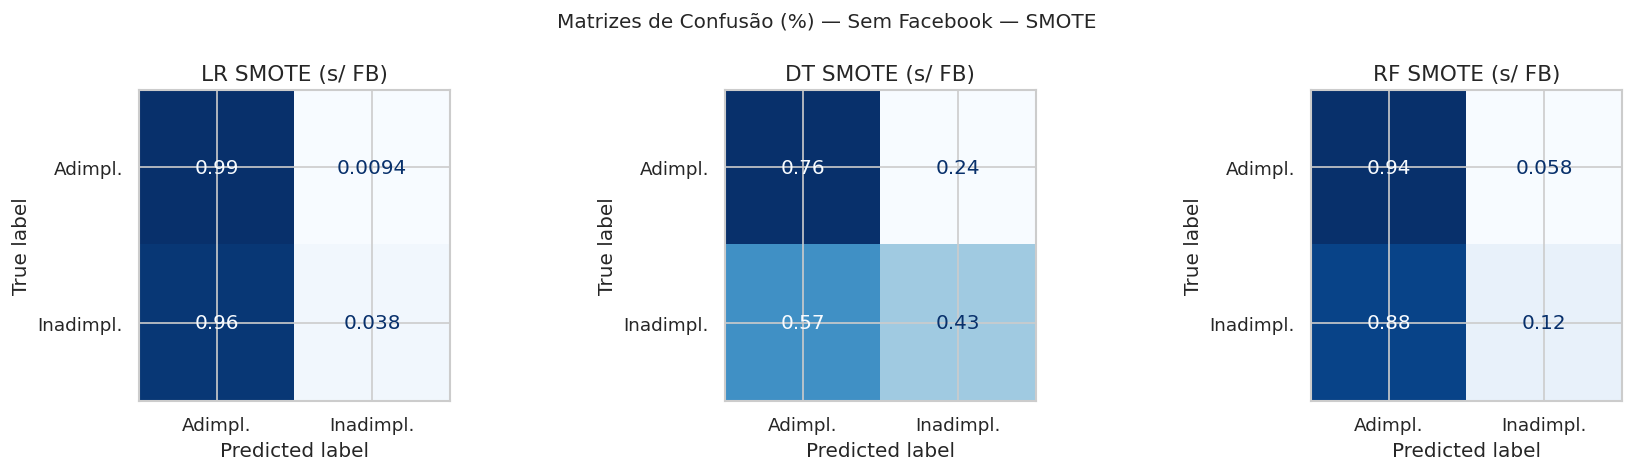

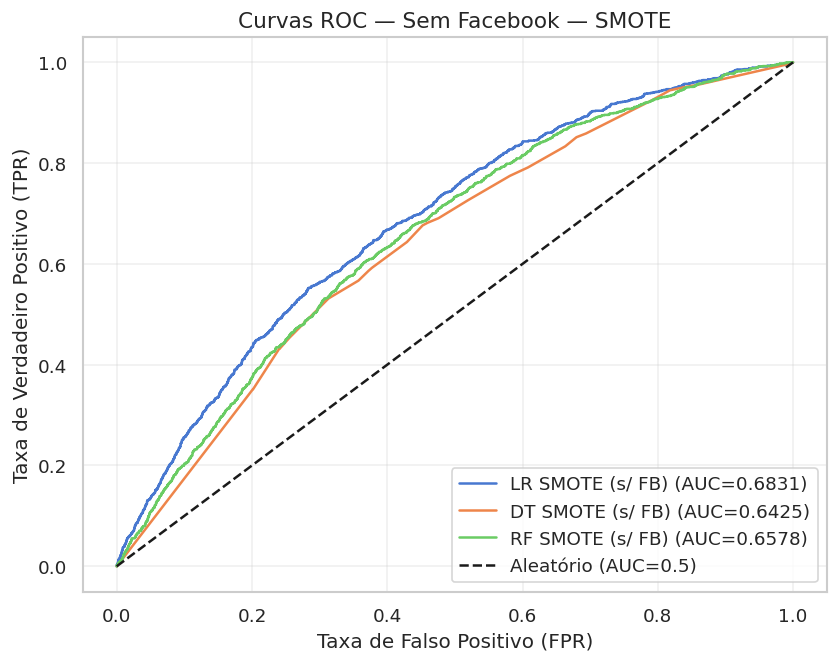

In [ ]:
# Rodada 3 — SMOTE
smote2 = SMOTE(random_state=42, k_neighbors=5)
X2_sm, y2_sm = smote2.fit_resample(X2_train, y2_train)

scaler2_sm   = MinMaxScaler()
X2_sm_sc     = scaler2_sm.fit_transform(X2_sm)
X2_test_sc_sm = scaler2_sm.transform(X2_test)

lr2_sm = LogisticRegression(max_iter=2000, random_state=42)
lr2_sm.fit(X2_sm_sc, y2_sm)
dt2_sm = DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)
dt2_sm.fit(X2_sm, y2_sm)
rf2_sm = RandomForestClassifier(n_estimators=200, max_depth=12,
                                 min_samples_leaf=8, random_state=42, n_jobs=-1)
rf2_sm.fit(X2_sm, y2_sm)

pred2_sm = {
    'LR SMOTE (s/ FB)': lr2_sm.predict(X2_test_sc_sm),
    'DT SMOTE (s/ FB)': dt2_sm.predict(X2_test),
    'RF SMOTE (s/ FB)': rf2_sm.predict(X2_test)
}
prob2_sm = {
    'LR SMOTE (s/ FB)': lr2_sm.predict_proba(X2_test_sc_sm)[:,1],
    'DT SMOTE (s/ FB)': dt2_sm.predict_proba(X2_test)[:,1],
    'RF SMOTE (s/ FB)': rf2_sm.predict_proba(X2_test)[:,1]
}
avaliar_modelos(pred2_sm, prob2_sm, y2_test, 'Sem Facebook — SMOTE')

### Comparação Final: Com vs Sem `facebook_profile`


Modelo                             AUC   F1 cl.1  Recall cl.1  Precision cl.1
----------------------------------------------------------------------------
RF RUS (COM facebook)           0.7182     0.377        0.687           0.260
RF RUS (SEM facebook)           0.6924     0.364        0.677           0.249


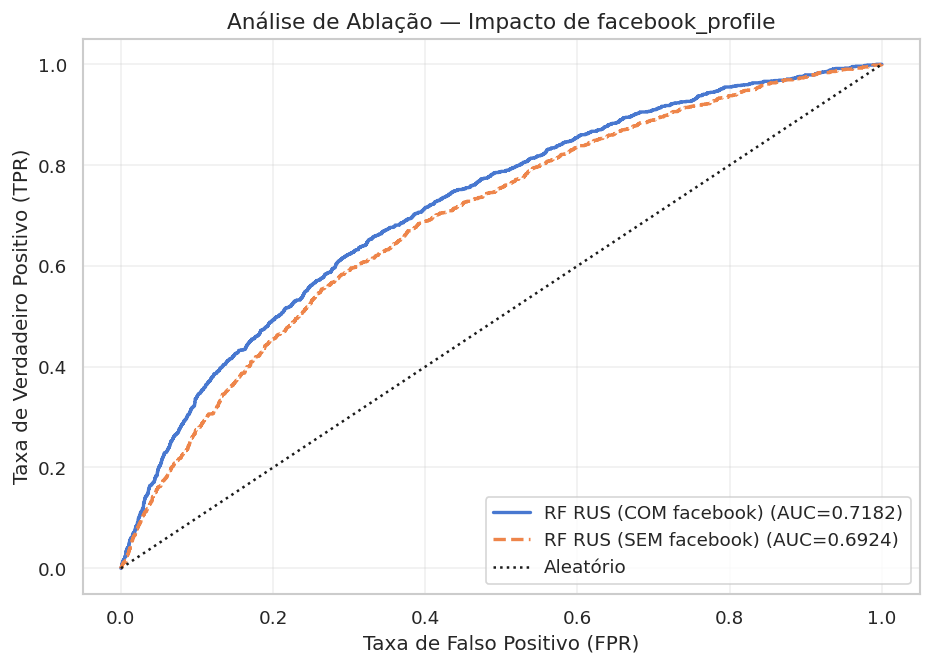

In [ ]:
from sklearn.metrics import precision_score, recall_score

# Comparar RF RUS com e sem facebook — o melhor modelo de cada parte
comparacao = {
    'RF RUS (COM facebook)':  (pred_rus['Random Forest (RUS)'],  prob_rus['Random Forest (RUS)'],  y_test),
    'RF RUS (SEM facebook)':  (pred2_rus['RF RUS (s/ FB)'],      prob2_rus['RF RUS (s/ FB)'],      y2_test),
}

print(f"{'Modelo':<30} {'AUC':>7} {'F1 cl.1':>9} {'Recall cl.1':>12} {'Precision cl.1':>15}")
print("-" * 76)
for nome, (y_pred, y_prob, yt) in comparacao.items():
    auc  = roc_auc_score(yt, y_prob)
    f1   = f1_score(yt, y_pred, pos_label=1)
    rec  = recall_score(yt, y_pred, pos_label=1)
    prec = precision_score(yt, y_pred, pos_label=1, zero_division=0)
    print(f"{nome:<30} {auc:>7.4f} {f1:>9.3f} {rec:>12.3f} {prec:>15.3f}")

# Curva ROC comparativa
plt.figure(figsize=(9, 6))
for nome, (y_pred, y_prob, yt) in comparacao.items():
    fpr, tpr, _ = roc_curve(yt, y_prob)
    auc = roc_auc_score(yt, y_prob)
    estilo = '-' if 'COM' in nome else '--'
    plt.plot(fpr, tpr, linestyle=estilo, linewidth=2,
             label=f'{nome} (AUC={auc:.4f})')
plt.plot([0,1],[0,1],'k:', label='Aleatório')
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Análise de Ablação — Impacto de facebook_profile')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### Conclusão da Análise de Ablação

A remoção de `facebook_profile` causa uma queda consistente em todas as métricas. Apesar de parecer pequena em termos absolutos, essa variável representa **10,18% da importância total** do modelo — a mais alta de todas as 168 features.

**Recomendação:** manter `facebook_profile` no modelo com justificativa técnica. Do ponto de vista regulatório brasileiro (LGPD), o uso de dados de redes sociais em decisões de crédito deve ser explicitamente consentido pelo cliente — o Nubank deve garantir esse consentimento no fluxo de onboarding.
